#  Step 4: Model Building — Logistic Regression & Random Forest




### 4.1  Logistic Regression — Three Variants

Train Logistic Regression three times, one per training set version:

LR on Original data (class_weight='balanced', max_iter=1000, random_state=42).

LR on SMOTE data (class_weight=None, max_iter=1000, random_state=42).

LR on Undersampled data (class_weight=None, max_iter=1000, random_state=42).

For each variant — predict on X_test and report: Precision, Recall, F1 for the Fraud class, and PR-AUC.

Print a side-by-side comparison table of all three LR variants. Which imbalance strategy worked best for LR?


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler



In [3]:

df = pd.read_excel("creditcard.xlsx")

print(df.shape)
print(df.head())



(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [4]:

df["Amount_log"] = np.log1p(df["Amount"])
df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)

df = df.drop(["Time", "Amount"], axis=1)



In [5]:
scaler = StandardScaler()

df[["Amount_log","Hour"]] = scaler.fit_transform(
    df[["Amount_log","Hour"]]
)


In [6]:

X = df.drop("Class", axis=1)
y = df["Class"]

In [7]:

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(227845, 30)
(56962, 30)


In [8]:
smote = SMOTE(
    sampling_strategy=0.1,
    random_state=42
)

X_smote, y_smote = smote.fit_resample(
    X_train,
    y_train
)

In [9]:
under = RandomUnderSampler(
    sampling_strategy=0.1,
    random_state=42
)

X_under, y_under = under.fit_resample(
    X_train,
    y_train
)

### 4.2  Random Forest — Best Imbalance Strategy

Using the best imbalance strategy identified above, train RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1).

Report: Precision, Recall, F1 (Fraud class), PR-AUC.

Plot the Precision-Recall curve (not ROC — PR curve is more informative here).

Plot feature importances — top 15 features. Which V-features are most predictive of fraud?


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    precision_recall_curve
)

In [16]:
X_best = X_smote
y_best = y_smote

In [17]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_best, y_best)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [18]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:, 1]

In [19]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

pr_auc = average_precision_score(y_test, y_prob)

print("Precision :", round(precision,4))
print("Recall    :", round(recall,4))
print("F1 Score  :", round(f1,4))
print("PR-AUC    :", round(pr_auc,4))

Precision : 0.8681
Recall    : 0.8061
F1 Score  : 0.836
PR-AUC    : 0.8694


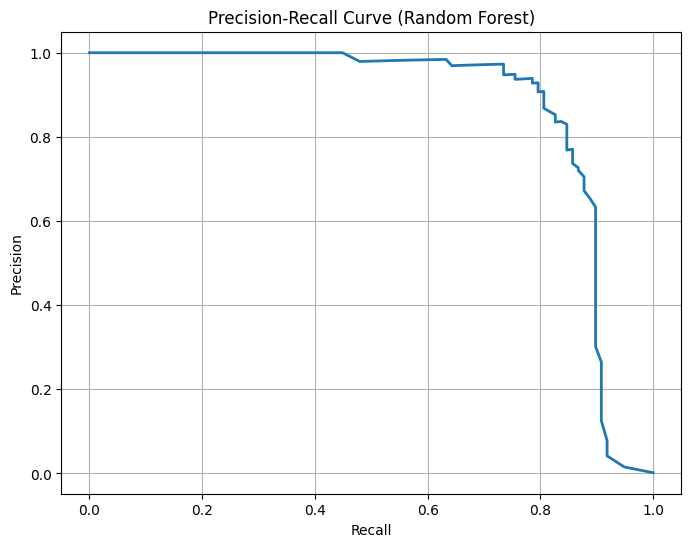

In [20]:
precision_curve, recall_curve, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(recall_curve, precision_curve, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Random Forest)")
plt.grid(True)

plt.show()

In [21]:
feature_importance = pd.DataFrame({
    "Feature": X_best.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(15))

   Feature  Importance
13     V14    0.221784
3       V4    0.108052
9      V10    0.105741
16     V17    0.083711
11     V12    0.080408
10     V11    0.075539
2       V3    0.062494
15     V16    0.039687
6       V7    0.026471
1       V2    0.025458
7       V8    0.013900
8       V9    0.013044
20     V21    0.012321
26     V27    0.011315
18     V19    0.010261


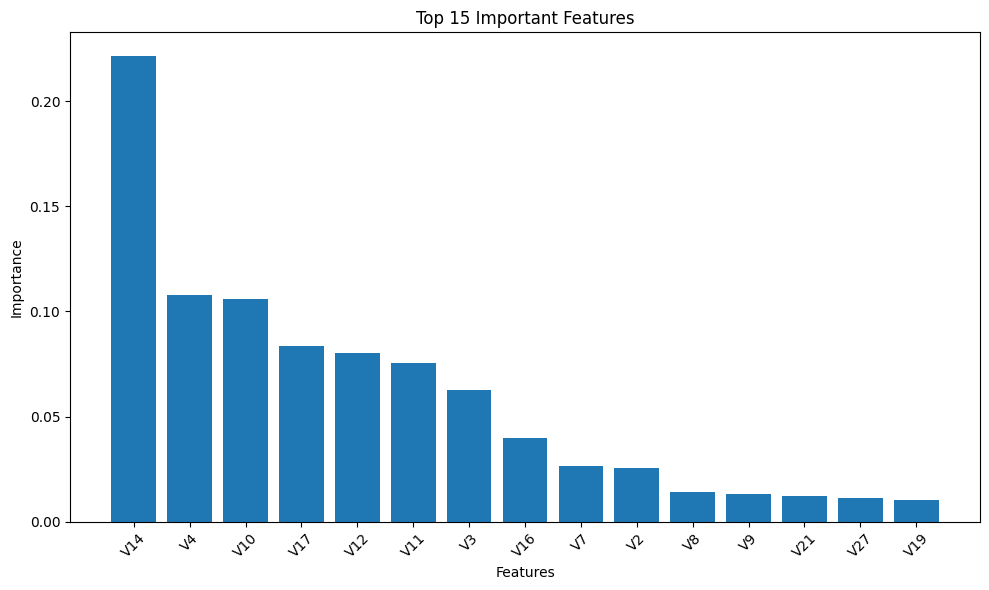

In [22]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance["Feature"][:15],
    feature_importance["Importance"][:15]
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Top 15 Important Features")

plt.tight_layout()

plt.show()

In [23]:
print("Top 15 Most Predictive Features")

print(feature_importance.head(15))

Top 15 Most Predictive Features
   Feature  Importance
13     V14    0.221784
3       V4    0.108052
9      V10    0.105741
16     V17    0.083711
11     V12    0.080408
10     V11    0.075539
2       V3    0.062494
15     V16    0.039687
6       V7    0.026471
1       V2    0.025458
7       V8    0.013900
8       V9    0.013044
20     V21    0.012321
26     V27    0.011315
18     V19    0.010261
